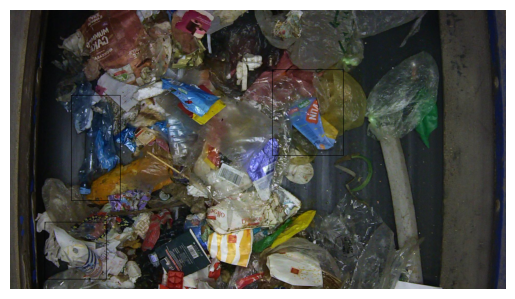

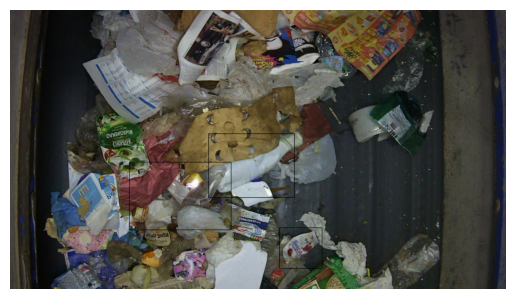

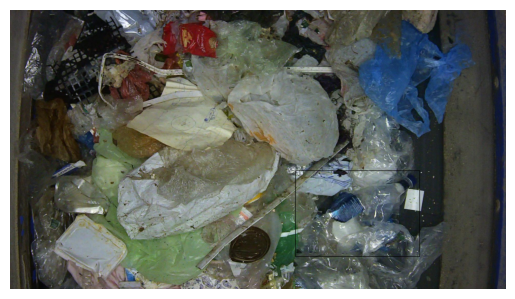

In [4]:
import os
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

def yolo_to_absolute(size, box):
    """ Convert YOLO format (x_center, y_center, width, height) to absolute coordinates. """
    w, h = size
    x_center, y_center, width, height = box
    x_min = int((x_center - width / 2) * w)
    y_min = int((y_center - height / 2) * h)
    x_max = int((x_center + width / 2) * w)
    y_max = int((y_center + height / 2) * h)
    return [x_min, y_min, x_max, y_max]

class WasteDetectionDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.image_filenames = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        image_filename = self.image_filenames[idx]
        image_path = os.path.join(self.image_dir, image_filename)
        label_path = os.path.join(self.label_dir, image_filename.replace('.jpg', '.txt'))
        
        # Load image
        image = Image.open(image_path).convert("RGB")
        width, height = image.size
        
        # Load label (YOLO format)
        boxes = []
        labels = []
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                class_id = int(parts[0])
                bbox = list(map(float, parts[1:]))
                absolute_bbox = yolo_to_absolute((width, height), bbox)
                labels.append(class_id)
                boxes.append(absolute_bbox)
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.long)

# Define image transformations with augmentation
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Dataset and DataLoader
train_dataset = WasteDetectionDataset(r"C:\Users\Alfina\Downloads\archive\Warp-D\train\images", r"C:\Users\Alfina\Downloads\archive\Warp-D\train\labels", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = WasteDetectionDataset(r"C:\Users\Alfina\Downloads\archive\Warp-D\test\images", r"C:\Users\Alfina\Downloads\archive\Warp-D\test\labels", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Function to visualize sample images with bounding boxes
def visualize_sample(image_dir, label_dir, num_samples=3):
    sample_images = os.listdir(image_dir)[:num_samples]
    for image_filename in sample_images:
        image_path = os.path.join(image_dir, image_filename)
        label_path = os.path.join(label_dir, image_filename.replace('.jpg', '.txt'))
        
        image = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(image)
        width, height = image.size
        
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                class_id = int(parts[0])
                bbox = list(map(float, parts[1:]))
                absolute_bbox = yolo_to_absolute((width, height), bbox)
                draw.rectangle(absolute_bbox, outline="black", width=2)
                draw.text((absolute_bbox[0], absolute_bbox[1]), str(class_id), fill="black")
        
        plt.imshow(image)
        plt.axis("off")
        plt.show()

# Visualize some samples
visualize_sample(r"C:\Users\Alfina\Downloads\archive\Warp-D\train\images", r"C:\Users\Alfina\Downloads\archive\Warp-D\train\labels")


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.models import densenet121, maxvit_t
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def yolo_to_multilabel(label_path, num_classes=28):
    """ Convert YOLO labels to multi-label format (one-hot encoded). """
    labels = np.zeros(num_classes, dtype=np.float32)
    try:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) > 0:
                    class_id = int(parts[0])
                    if 0 <= class_id < num_classes:
                        labels[class_id] = 1  
    except Exception as e:
        print(f"Error reading label file {label_path}: {e}")
    return labels

class WasteDataset(Dataset):
    def __init__(self, image_dir, label_dir, num_classes=28, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.num_classes = num_classes
        self.image_filenames = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        image_filename = self.image_filenames[idx]
        image_path = os.path.join(self.image_dir, image_filename)
        label_path = os.path.join(self.label_dir, image_filename.replace('.jpg', '.txt'))
        
        image = Image.open(image_path).convert("RGB")
        labels = yolo_to_multilabel(label_path, self.num_classes)
        
        if self.transform:
            image = self.transform(image)
        
        return image.to(device), torch.tensor(labels, dtype=torch.float32).to(device)

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Dataset and DataLoader
train_dataset = WasteDataset("C:/Users/Alfina/Downloads/archive/Warp-D/train/images", "C:/Users/Alfina/Downloads/archive/Warp-D/train/labels", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = WasteDataset("C:/Users/Alfina/Downloads/archive/Warp-D/test/images", "C:/Users/Alfina/Downloads/archive/Warp-D/test/labels", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Define 2S_DenseViT model
class TwoStreamDenseViT(nn.Module):
    def __init__(self, num_classes=28):
        super(TwoStreamDenseViT, self).__init__()
        self.densenet = densenet121(pretrained=True)
        self.densenet.classifier = nn.Identity()
        
        self.maxvit = maxvit_t(pretrained=True)
        self.maxvit.classifier = nn.Identity()
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc = nn.Linear(1024 + 512, num_classes)
        
        # Freeze initial layers
        for param in list(self.densenet.features.parameters())[:50]:
            param.requires_grad = False
        for param in list(self.maxvit.parameters())[:50]:
            param.requires_grad = False
        
    def forward(self, x):
        densenet_features = self.densenet(x)
        maxvit_features = self.maxvit(x)
        maxvit_features = self.pool(maxvit_features)
        maxvit_features = torch.flatten(maxvit_features, start_dim=1)
        combined = torch.cat((densenet_features, maxvit_features), dim=1)
        return self.fc(combined)

# Initialize model
model = TwoStreamDenseViT(num_classes=28).to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

def train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=13, early_stop_patience=3):
    model.train()
    best_loss = float('inf')
    patience = early_stop_patience
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
        
        scheduler.step()
        
        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience = early_stop_patience
            torch.save(model.state_dict(), r"C:\wasteproject\2DenseViT_model.pth")
            print("Model improved, saved as 2DenseViT_model.pth")
        else:
            patience -= 1
            if patience == 0:
                print("Early stopping triggered.")
                break

train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=13)

Epoch 1/13, Loss: 0.3200
Model improved, saved as 2DenseViT_model.pth
Epoch 2/13, Loss: 0.2901
Model improved, saved as 2DenseViT_model.pth
Epoch 3/13, Loss: 0.2701
Model improved, saved as 2DenseViT_model.pth
Epoch 4/13, Loss: 0.2537
Model improved, saved as 2DenseViT_model.pth
Epoch 5/13, Loss: 0.2383
Model improved, saved as 2DenseViT_model.pth
Epoch 6/13, Loss: 0.1826
Model improved, saved as 2DenseViT_model.pth
Epoch 7/13, Loss: 0.1528
Model improved, saved as 2DenseViT_model.pth
Epoch 8/13, Loss: 0.1325
Model improved, saved as 2DenseViT_model.pth
Epoch 9/13, Loss: 0.1104
Model improved, saved as 2DenseViT_model.pth


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.models import densenet121, maxvit_t
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def yolo_to_multilabel(label_path, num_classes=28):
    """ Convert YOLO labels to multi-label format (one-hot encoded). """
    labels = np.zeros(num_classes, dtype=np.float32)
    try:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) > 0:
                    class_id = int(parts[0])
                    if 0 <= class_id < num_classes:
                        labels[class_id] = 1  
    except Exception as e:
        print(f"Error reading label file {label_path}: {e}")
    return labels

class WasteDataset(Dataset):
    def __init__(self, image_dir, label_dir, num_classes=28, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.num_classes = num_classes
        self.image_filenames = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        image_filename = self.image_filenames[idx]
        image_path = os.path.join(self.image_dir, image_filename)
        label_path = os.path.join(self.label_dir, image_filename.replace('.jpg', '.txt'))
        
        image = Image.open(image_path).convert("RGB")
        labels = yolo_to_multilabel(label_path, self.num_classes)
        
        if self.transform:
            image = self.transform(image)
        
        return image.to(device), torch.tensor(labels, dtype=torch.float32).to(device)

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Dataset and DataLoader
train_dataset = WasteDataset("C:/Users/Alfina/Downloads/archive/Warp-D/train/images", "C:/Users/Alfina/Downloads/archive/Warp-D/train/labels", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = WasteDataset("C:/Users/Alfina/Downloads/archive/Warp-D/test/images", "C:/Users/Alfina/Downloads/archive/Warp-D/test/labels", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Define 2S_DenseViT model
class TwoStreamDenseViT(nn.Module):
    def __init__(self, num_classes=28):
        super(TwoStreamDenseViT, self).__init__()
        self.densenet = densenet121(pretrained=True)
        self.densenet.classifier = nn.Identity()
        
        self.maxvit = maxvit_t(pretrained=True)
        self.maxvit.classifier = nn.Identity()
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc = nn.Linear(1024 + 512, num_classes)
        
        # Freeze initial layers
        for param in list(self.densenet.features.parameters())[:50]:
            param.requires_grad = False
        for param in list(self.maxvit.parameters())[:50]:
            param.requires_grad = False
        
    def forward(self, x):
        densenet_features = self.densenet(x)
        maxvit_features = self.maxvit(x)
        maxvit_features = self.pool(maxvit_features)
        maxvit_features = torch.flatten(maxvit_features, start_dim=1)
        combined = torch.cat((densenet_features, maxvit_features), dim=1)
        return self.fc(combined)

# Initialize model
model = TwoStreamDenseViT(num_classes=28).to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

def train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=3, early_stop_patience=3):
    model.train()
    best_loss = float('inf')
    patience = early_stop_patience
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
        
        scheduler.step()
        
        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience = early_stop_patience
            torch.save(model.state_dict(), r"C:\wasteproject\2DenseViT_model.pth")
            print("Model improved, saved as 2DenseViT_model.pth")
        else:
            patience -= 1
            if patience == 0:
                print("Early stopping triggered.")
                break

train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=3)

Epoch 1/3, Loss: 0.3199
Model improved, saved as 2DenseViT_model.pth
Epoch 2/3, Loss: 0.2899
Model improved, saved as 2DenseViT_model.pth
Epoch 3/3, Loss: 0.2701
Model improved, saved as 2DenseViT_model.pth


In [3]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the image preprocessing function
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the trained model
model = TwoStreamDenseViT(num_classes=28).to(device)
model.load_state_dict(torch.load(r"C:\wasteproject\2DenseViT_model.pth"))
model.eval()

# Function to classify a single image
def classify_image(image_path, threshold=0.9):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension
    
    with torch.no_grad():
        output = torch.sigmoid(model(image))  # Get predictions
        predicted_labels = (output > threshold).cpu().numpy().astype(int)[0]  # Convert to binary labels
    
    # Load class names (assuming class names are stored in dataset.yaml)
    class_names = [f"Class {i}" for i in range(28)]  # Replace with actual class names if available
    
    # Get predicted class names
    detected_classes = [class_names[i] for i in range(28) if predicted_labels[i] == 1]
    
    return detected_classes

# Test with an image
image_path = r"C:\Users\Alfina\Downloads\archive\Warp-D\test\images\prepared_data_all_MGS-27-Oct_14-00-43.jpg"  # Replace with an actual image path
predictions = classify_image(image_path)  #27,12

print("Predicted Classes:", predictions)


NameError: name 'TwoStreamDenseViT' is not defined

In [2]:
import torch
import torchvision.transforms as transforms
import yaml
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Set device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load class names from dataset.yaml
yaml_path = r"C:/Users/Alfina/Downloads/archive/Warp-D/dataset.yaml"
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load trained model
model = TwoStreamDenseViT(num_classes=len(class_names)).to(device)
model.load_state_dict(torch.load(r"C:\wasteproject\2DenseViT_model.pth"))
model.eval()

# Function to classify an image and draw bounding boxes
def classify_and_visualize(image_path, label_path, threshold=0.3):
    if not os.path.exists(image_path):
        print("Image file not found!")
        return None, None
    
    if not os.path.exists(label_path):
        print(f"Label file not found: {label_path}")
        return None, None

    # Load image
    image = Image.open(image_path).convert("RGB")
    original_image = image.copy()  # Keep a copy for visualization
    image_resized = transform(image).unsqueeze(0).to(device)  # Preprocess
    
    # Predict labels
    with torch.no_grad():
        output = torch.sigmoid(model(image_resized))
        predicted_labels = (output > threshold).cpu().numpy().astype(int)[0]

    # Extract detected class names
    detected_classes = [class_names[i] for i in range(len(class_names)) if predicted_labels[i] == 1]

    # Draw bounding boxes if label file exists
    image_draw = ImageDraw.Draw(original_image)
    img_width, img_height = original_image.size

    try:
        with open(label_path, "r", encoding="utf-8") as f:  # ✅ FIXED ENCODING ISSUE HERE
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue  # Skip invalid lines

                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])

                # Convert YOLO format to absolute coordinates
                x1 = int((x_center - width / 2) * img_width)
                y1 = int((y_center - height / 2) * img_height)
                x2 = int((x_center + width / 2) * img_width)
                y2 = int((y_center + height / 2) * img_height)

                # Draw bounding box
                image_draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
                image_draw.text((x1, y1 - 10), f"{class_names[class_id]} ({class_id})", fill="red")

                print(f"Detected: {class_names[class_id]} (ID: {class_id}) at ({x1}, {y1}, {x2}, {y2})")
    
    except UnicodeDecodeError:
        print("Error reading label file. Try opening it with a text editor and re-saving as UTF-8.")

    return original_image, detected_classes

# Test with an image and label
image_path = r"C:\Users\Alfina\Downloads\archive\Warp-D\test\images\prepared_data_all_MGS-05-Nov_01-49-15.jpg"
label_path = image_path.replace("images", "labels").replace(".jpg", ".txt")  # Fix label path replacement

result_image, predictions = classify_and_visualize(image_path, label_path)

if result_image:
    # ✅ SHOW IMAGE INSIDE SCRIPT (Matplotlib)
    plt.figure(figsize=(8, 6))
    plt.imshow(result_image)
    plt.axis("off")  # Hide axes
    plt.title(f"Predicted Classes: {', '.join(predictions)}")
    plt.show()

NameError: name 'TwoStreamDenseViT' is not defined

In [1]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_with_threshold(model, test_loader, thresholds):
    model.eval()
    best_f1 = 0
    best_threshold = 0
    results = {}

    with torch.no_grad():
        y_true = []
        y_pred_scores = []

        for images, labels in test_loader:
            outputs = torch.sigmoid(model(images))
            y_true.extend(labels.cpu().numpy())
            y_pred_scores.extend(outputs.cpu().numpy())

        y_true = np.array(y_true)
        y_pred_scores = np.array(y_pred_scores)

        for threshold in thresholds:
            y_pred = (y_pred_scores > threshold).astype(int)

            # ✅ Convert each row to a set (order doesn't matter)
            y_true_sets = [set(np.where(row == 1)[0]) for row in y_true]
            y_pred_sets = [set(np.where(row == 1)[0]) for row in y_pred]

            # ✅ Compute metrics ignoring order
            precision = np.mean([
                len(y_t & y_p) / len(y_p) if len(y_p) > 0 else 1
                for y_t, y_p in zip(y_true_sets, y_pred_sets)
            ]) * 100

            recall = np.mean([
                len(y_t & y_p) / len(y_t) if len(y_t) > 0 else 1
                for y_t, y_p in zip(y_true_sets, y_pred_sets)
            ]) * 100

            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            results[threshold] = (precision, recall, f1)

            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold

    print("\n📊 Threshold Tuning Results (Order Ignored):")
    for t, (p, r, f) in results.items():
        print(f"  🔹 Threshold {t:.2f} → Precision: {p:.2f}%, Recall: {r:.2f}%, F1-score: {f:.2f}%")

    print(f"\n✅ Best Threshold: {best_threshold:.2f} with F1-score: {best_f1:.2f}%")
    return best_threshold

# Run evaluation
thresholds = np.linspace(0.1, 0.9, 9)
BEST_THRESHOLD = evaluate_with_threshold(model, test_loader, thresholds)


NameError: name 'np' is not defined

In [24]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Suppress warnings

import os
import torch
import numpy as np
import yaml
from sklearn.metrics import precision_score, recall_score, f1_score
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.models import densenet121, maxvit_t
import torch.nn as nn
# Custom dataset class
class WasteDataset(Dataset):
    def __init__(self, image_dir, label_dir, num_classes=28, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.num_classes = num_classes
        self.image_filenames = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        image_filename = self.image_filenames[idx]
        image_path = os.path.join(self.image_dir, image_filename)
        label_path = os.path.join(self.label_dir, image_filename.replace('.jpg', '.txt'))
        
        image = Image.open(image_path).convert("RGB")
        labels = yolo_to_multilabel(label_path, self.num_classes)
        
        if self.transform:
            image = self.transform(image)
        
        return image.to(device), torch.tensor(labels, dtype=torch.float32).to(device)

# Image transformations

# Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Define the Two-Stream DenseViT model
class TwoStreamDenseViT(nn.Module):
    def __init__(self, num_classes=28):
        super(TwoStreamDenseViT, self).__init__()
        self.densenet = densenet121(pretrained=True)
        self.densenet.classifier = nn.Identity()
        
        self.maxvit = maxvit_t(pretrained=True)
        self.maxvit.classifier = nn.Identity()
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc = nn.Linear(1024 + 512, num_classes)
        
        # Freeze initial layers
        for param in list(self.densenet.features.parameters())[:50]:
            param.requires_grad = False
        for param in list(self.maxvit.parameters())[:50]:
            param.requires_grad = False
        
    def forward(self, x):
        densenet_features = self.densenet(x)
        maxvit_features = self.maxvit(x)
        maxvit_features = self.pool(maxvit_features)
        maxvit_features = torch.flatten(maxvit_features, start_dim=1)
        combined = torch.cat((densenet_features, maxvit_features), dim=1)
        return self.fc(combined)

# Load class names from dataset.yaml
yaml_path = r"C:/Users/Alfina/Downloads/archive/Warp-D/dataset.yaml"
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

#Dataset and DataLoader
test_dataset = WasteDataset(
    "C:/Users/Alfina/Downloads/archive/Warp-D/test/images", 
    "C:/Users/Alfina/Downloads/archive/Warp-D/test/labels", 
    transform=transform
)#

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
# Load trained model
model = TwoStreamDenseViT(num_classes=len(class_names)).to(device)
model.load_state_dict(torch.load(r"C:\wasteproject\2DenseViT_model.pth", map_location=device))
model.eval()

best_threshold=0.3
def evaluate_model_accuracy_ignore_order(model, test_loader, best_threshold):
    model.eval()
    y_true = []
    y_pred_scores = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.cpu().numpy()  # Convert labels to numpy
            
            outputs = torch.sigmoid(model(images))
            y_true.extend(labels)
            y_pred_scores.extend(outputs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred_scores = np.array(y_pred_scores)

    # Apply threshold
    y_pred = (y_pred_scores > best_threshold).astype(int)

    # Convert each row into a set of predicted and true class indices
    correct_predictions = []
    total_samples = y_true.shape[0]

    for true_labels, pred_labels in zip(y_true, y_pred):
        true_classes = set(np.where(true_labels == 1)[0])  # Set of ground truth labels
        pred_classes = set(np.where(pred_labels == 1)[0])  # Set of predicted labels

        # If all predicted classes exist in true classes, count as correct
        correct_predictions.append(len(pred_classes & true_classes) / (len(true_classes) + 1e-10))  

    # Compute accuracy ignoring order
    order_ignored_accuracy = np.mean(correct_predictions) * 100

    print(f"✅ Multi-Label Accuracy (Ignoring Order): {order_ignored_accuracy:.2f}%")

    return order_ignored_accuracy

# 🔹 Run evaluation
evaluate_model_accuracy_ignore_order(model, test_loader,best_threshold)


✅ Multi-Label Accuracy (Ignoring Order): 22.09%


np.float64(22.08819862458309)

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Suppress warnings

import os
import torch
import numpy as np
import yaml
from sklearn.metrics import precision_score, recall_score, f1_score
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.models import densenet121, maxvit_t
import torch.nn as nn
from PIL import Image

# Custom dataset class
class WasteDataset(Dataset):
    def __init__(self, image_dir, label_dir, num_classes=28, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.num_classes = num_classes
        self.image_filenames = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        image_filename = self.image_filenames[idx]
        image_path = os.path.join(self.image_dir, image_filename)
        label_path = os.path.join(self.label_dir, image_filename.replace('.jpg', '.txt'))
        
        image = Image.open(image_path).convert("RGB")
        labels = yolo_to_multilabel(label_path, self.num_classes)
        
        if self.transform:
            image = self.transform(image)
        
        return image.to(device), torch.tensor(labels, dtype=torch.float32).to(device)

# Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the Two-Stream DenseViT model
class TwoStreamDenseViT(nn.Module):
    def __init__(self, num_classes=28):
        super(TwoStreamDenseViT, self).__init__()
        self.densenet = densenet121(pretrained=True)
        self.densenet.classifier = nn.Identity()
        
        self.maxvit = maxvit_t(pretrained=True)
        self.maxvit.classifier = nn.Identity()
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc = nn.Linear(1024 + 512, num_classes)
        
        # Freeze initial layers
        for param in list(self.densenet.features.parameters())[:50]:
            param.requires_grad = False
        for param in list(self.maxvit.parameters())[:50]:
            param.requires_grad = False
        
    def forward(self, x):
        densenet_features = self.densenet(x)
        maxvit_features = self.maxvit(x)
        maxvit_features = self.pool(maxvit_features)
        maxvit_features = torch.flatten(maxvit_features, start_dim=1)
        combined = torch.cat((densenet_features, maxvit_features), dim=1)
        return self.fc(combined)

# Load class names from dataset.yaml
yaml_path = r"C:/Users/Alfina/Downloads/archive/Warp-D/dataset.yaml"
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]

# Define image transformations with augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Dataset and DataLoader
test_dataset = WasteDataset(
    "C:/Users/Alfina/Downloads/archive/Warp-D/test/images", 
    "C:/Users/Alfina/Downloads/archive/Warp-D/test/labels", 
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load trained model
model = TwoStreamDenseViT(num_classes=len(class_names)).to(device)
model.load_state_dict(torch.load(r"C:\wasteproject\2DenseViT_model.pth", map_location=device))
model.eval()

best_threshold = 0.3
def evaluate_model_accuracy_ignore_order(model, test_loader, best_threshold):
    model.eval()
    y_true = []
    y_pred_scores = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.cpu().numpy()  # Convert labels to numpy
            
            outputs = torch.sigmoid(model(images))
            y_true.extend(labels)
            y_pred_scores.extend(outputs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred_scores = np.array(y_pred_scores)

    # Apply threshold
    y_pred = (y_pred_scores > best_threshold).astype(int)

    # Convert each row into a set of predicted and true class indices
    correct_predictions = []
    total_samples = y_true.shape[0]

    for true_labels, pred_labels in zip(y_true, y_pred):
        true_classes = set(np.where(true_labels == 1)[0])  # Set of ground truth labels
        pred_classes = set(np.where(pred_labels == 1)[0])  # Set of predicted labels

        # If all predicted classes exist in true classes, count as correct
        correct_predictions.append(len(pred_classes & true_classes) / (len(true_classes) + 1e-10))  

    # Compute accuracy ignoring order
    order_ignored_accuracy = np.mean(correct_predictions) * 100

    print(f"✅ Multi-Label Accuracy (Ignoring Order): {order_ignored_accuracy:.2f}%")

    return order_ignored_accuracy

# 🔹 Run evaluation
evaluate_model_accuracy_ignore_order(model, test_loader, best_threshold)


✅ Multi-Label Accuracy (Ignoring Order): 7.43%


np.float64(7.42975734324705)